# Application 2 — Electron microscopy: zebrafish neuronal nuclei (NucMM-Z)

**Modality:** serial-section electron microscopy (EM), downsampled to 0.48 × 0.51 × 0.51 µm voxels (z, y, x).
**Objects:** neuronal nuclei in the brain of a larval zebrafish.

**Dataset:** NucMM — Lin, Z., Wei, D., Petkova, M. D., Wu, Y., Ahmed, Z., Swaroop, K., Zou, S., Wendt, N., Boulanger-Weill, J.,
Wang, X., Dhanyasi, N., Arganda-Carreras, I., Engert, F., Lichtman, J., Pfister, H. (2021).
*NucMM dataset: 3D neuronal nuclei instance segmentation at sub-cubic millimeter scale.* MICCAI 2021, LNCS pp. 164–174,
[doi:10.1007/978-3-030-87193-2_16](https://doi.org/10.1007/978-3-030-87193-2_16).
Data release by the authors on HuggingFace, [`pytc/NucMM`](https://huggingface.co/datasets/pytc/NucMM) (commit `e571f8b`), licence MIT
(dataset card; the authors' data-request form states the same). Please cite the paper above if you use the data.

**What this notebook does:** reads one annotated validation crop (64 × 64 × 64 voxels, 606 labelled nuclei; the crop that
PyTorch Connectomics also uses for its NucMM-Z tutorial) from the authors' archive, derives one box per nucleus, loads the boxes into
the synchronized four-viewer layout, replays a mouse drag on one box, and exports native, COCO and YOLO files.

In [1]:
SHOW = False  # True: open the four napari windows (needs a desktop session)

if SHOW:
    get_ipython().run_line_magic("gui", "qt")

import json
from pathlib import Path

import numpy as np
from IPython.display import Image, display

import tutorial_utils as tu

CASE = "02_electron_microscopy_nucmm_z"
DATA = tu.data_dir('nucmm_z')  # $TURBOBOX_DATA/<subdir>, else ~/.cache/napari-turbobox/<subdir>
OUT = DATA / "export"
print("data directory:", tu.show_path(DATA))

data directory: ~/.cache/napari-turbobox/nucmm_z


## 1. Download


The authors distribute NucMM as two zip archives (NucMM-Z 662 MB, NucMM-M 395 MB). We need one crop, so the notebook reads only
the zip's directory and that crop's bytes over HTTP range requests (`tu.fetch_zip_member`, a few MB instead of hundreds).
`zipfile` checks each member's CRC-32, and the extracted files are compared with their sha256 hashes.
The URL is pinned to a commit of the authors' repository.

In [2]:
ZIP_URL = "https://huggingface.co/datasets/pytc/NucMM/resolve/e571f8b2e24fb89e4a5d8f088a537fa827fbef9a/NucMM-Z.zip"
CROP = "0000_0640_0896"  # start (z, y, x) of the crop in the full volume
img_path = tu.fetch_zip_member(
    ZIP_URL, f"Zebrafish (NucMM-Z)/Image/val/img_{CROP}.h5", DATA / f"img_{CROP}.h5",
    sha256="814aa1e6c02deb06752cabb667e264d1b051f6dd86b60cbfea5b5151ea1a1c35",
)
seg_path = tu.fetch_zip_member(
    ZIP_URL, f"Zebrafish (NucMM-Z)/Label/val/seg_{CROP}.h5", DATA / f"seg_{CROP}.h5",
    sha256="3cda053c72ccb5049ae8c827b45f1ddfba9b1f25b8b8d5b13cfa5e9e4106dcac",
)

## 2. Load the volume


Each HDF5 file holds one dataset, `main`, in `(z, y, x)` order. The files carry no voxel size; the paper gives 0.48 × 0.51 × 0.51 µm.
Boxes stay in voxel indices; `SCALE` only makes napari display the volume in µm.

In [3]:
import h5py

with h5py.File(img_path, "r") as f:
    image = f["main"][:]
with h5py.File(seg_path, "r") as f:
    labels = f["main"][:]
SCALE = (0.48, 0.51, 0.51)  # µm per voxel (z, y, x), NucMM paper
CONTRAST = None
print("image", image.shape, image.dtype, "| labels", labels.shape, labels.dtype, "|", len(np.unique(labels)) - 1, "nuclei")

image (64, 64, 64) uint8 | labels (64, 64, 64) uint32 | 606 nuclei


## 3. One box per object


Each labelled nucleus becomes the box from its first to its last voxel index on every axis.
The label ids come from the full volume, so they are sparse; `find_objects` handles that.
The crop cuts through nuclei at its faces, so boxes of nuclei that touch a face end at the face.

In [4]:
boxes, ids = tu.labels_to_boxes(labels)
upper = np.array(image.shape) - 1
at_face = np.any((boxes[:, 0] == 0) | (boxes[:, 1] == upper), axis=1)
print(len(boxes), "boxes;", int(at_face.sum()), "of them touch a face of the crop")

606 boxes; 342 of them touch a face of the crop


In [5]:
check = tu.check_boxes(boxes, image.shape)
print(f"{check['valid']} of {check['boxes']} boxes satisfy 0 <= min, max <= shape - 1, max - min >= 1")
extent = boxes[:, 1] - boxes[:, 0]
print("median box extent (z, y, x) in voxels:", np.median(extent, axis=0).tolist())

606 of 606 boxes satisfy 0 <= min, max <= shape - 1, max - min >= 1
median box extent (z, y, x) in voxels: [7.0, 8.0, 6.0]


## 4. The synchronized four-viewer layout

XY is the editable view; XZ, YZ and 3D are read-only and display the same box store.
`add_boxes` validates every box against the image shape, so a `ValueError` here would mean an invalid box.
The screenshot shows the four canvases (XY, XZ, YZ, 3D), each 2D view on a slice through one median-sized box.

606 boxes in the shared store; shapes drawn per view: [79, 81, 58, 606]


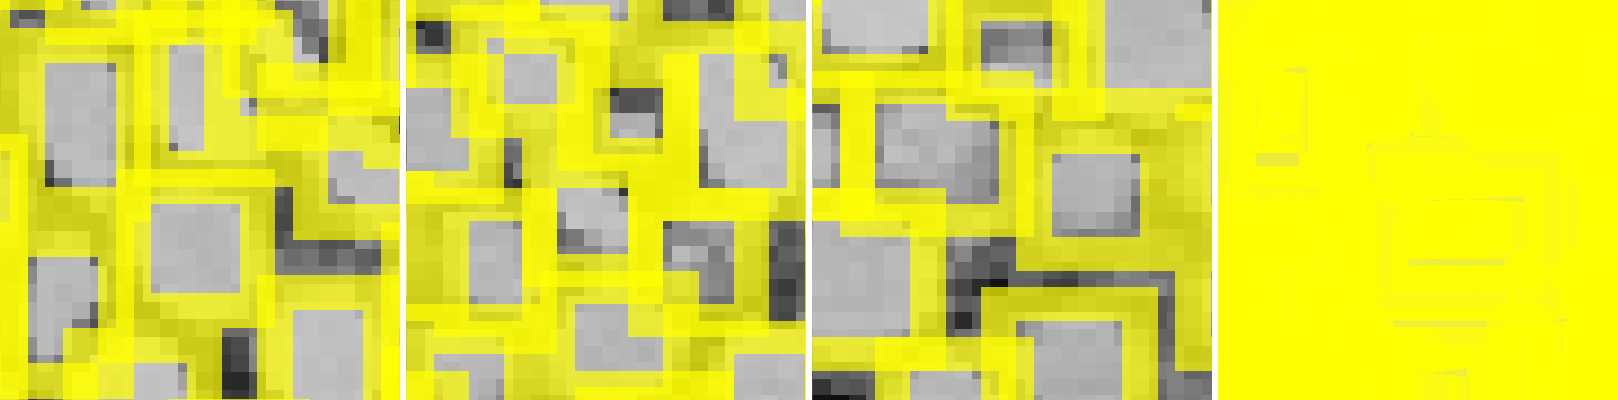

In [6]:
k = tu.pick_box(boxes)
viewers, layers = tu.four_viewer_layout(
    image, boxes, show=SHOW, scale=SCALE, contrast_limits=CONTRAST, focus_box=k
)
print(len(layers[0].bounding_boxes), "boxes in the shared store;",
      "shapes drawn per view:", [lyr.nshapes for lyr in layers])
shot = tu.RESULTS / f"{CASE}_views.png"
tu.screenshot(viewers, shot)
display(Image(filename=str(shot)))

## 5. Replaying a mouse drag

The drag below goes through napari's own mouse-event dispatch, the same path as a real mouse:
it grabs box `k` in the XY view at its centre and moves it by a quarter of its size in y and x.
We check that the box stays a valid box, that the read-only XZ and YZ views and the 3D view show it at the new position,
and that one undo step restores it.

In [7]:
drag = tu.replay_drag(viewers, layers, k)
print("shift (z, y, x):", drag["shift_zyx"], "intended:", drag["intended_shift_zyx"])
print("still a valid box:", drag["valid"])
print("read-only views show the moved box:", drag["views_show_moved_box"])
layers[0].undo()
print("undo restores all boxes:", np.array_equal(layers[0].bounding_boxes, boxes.astype(np.float32)))

shift (z, y, x): [0.0, 2.0, 1.0] intended: [0.0, 2.0, 1.0]
still a valid box: True
read-only views show the moved box: {'XZ (read-only)': True, 'YZ (read-only)': True, '3D (read-only)': True}


undo restores all boxes: True


## 6. Export

Native `boxes.npy` (the format of the control panel's import/export), COCO JSON with one 2D box per slice that a 3D box covers,
and one YOLO label file per slice. Slice images are named `slice_NNNN.png`; the exporter writes no image files.

In [8]:
counts = tu.export(layers[0].bounding_boxes, image.shape, OUT, label_ids=ids)
print(json.dumps(counts, indent=1))
print("files in", tu.show_path(OUT), ":", sorted(p.name for p in OUT.iterdir()))

{
 "boxes": 606,
 "coco_images": 64,
 "coco_annotations": 4402,
 "yolo_files": 64
}
files in ~/.cache/napari-turbobox/nucmm_z/export : ['boxes.npy', 'coco_per_slice.json', 'label_ids.npy', 'yolo']


In [9]:
result = dict(
    case=CASE,
    modality="serial-section electron microscopy",
    objects="neuronal nuclei (instance labels)",
    dataset="NucMM-Z, Lin et al. 2021 (MICCAI); HuggingFace pytc/NucMM (MIT)",
    volume=f"Image/val/img_{CROP}.h5",
    box_source="ground-truth instance labels",
    boxes_touching_crop_face=int(at_face.sum()),
)
result.update(check=check, export=counts, drag=drag, image_shape=list(image.shape), n_boxes=int(len(boxes)))
print(json.dumps({k: v for k, v in result.items() if k != "drag"}, indent=1))
tu.show_path(tu.save_result(CASE, result))

{
 "case": "02_electron_microscopy_nucmm_z",
 "modality": "serial-section electron microscopy",
 "objects": "neuronal nuclei (instance labels)",
 "dataset": "NucMM-Z, Lin et al. 2021 (MICCAI); HuggingFace pytc/NucMM (MIT)",
 "volume": "Image/val/img_0000_0640_0896.h5",
 "box_source": "ground-truth instance labels",
 "boxes_touching_crop_face": 342,
 "check": {
  "boxes": 606,
  "valid": 606
 },
 "export": {
  "boxes": 606,
  "coco_images": 64,
  "coco_annotations": 4402,
  "yolo_files": 64
 },
 "image_shape": [
  64,
  64,
  64
 ],
 "n_boxes": 606
}


'tutorials/results/02_electron_microscopy_nucmm_z.json'

In [10]:
if not SHOW:
    for v in viewers:
        v.close()